In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
0,19,1,27.900,0,1,0,0,1,19,27.90
1,18,0,33.770,1,0,0,1,0,0,0.00
2,28,0,33.000,3,0,0,1,0,0,0.00
3,33,0,22.705,0,0,1,0,0,0,0.00
4,32,0,28.880,0,0,1,0,0,0,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,1,0,0,0,0.00
1334,18,1,31.920,0,0,0,0,0,0,0.00
1335,18,1,36.850,0,0,0,1,0,0,0.00
1336,21,1,25.800,0,0,0,0,1,0,0.00


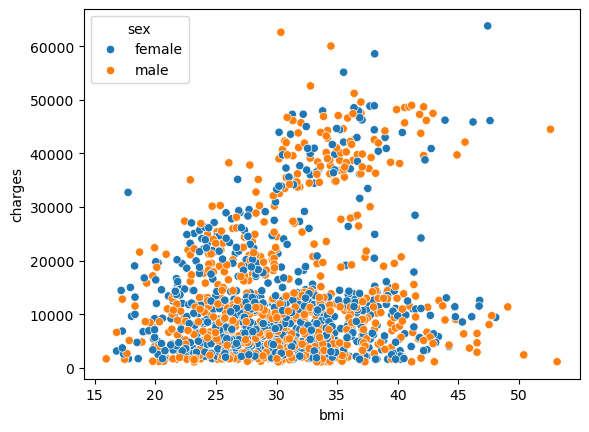

In [ ]:
insurance_data = pd.read_csv("insurance.csv")

X=insurance_data.drop(columns=["charges"])
Y = insurance_data["charges"]

X=pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)
gender_map = {
    "male":0,
    "female":1,
}

smoker_map = {
    "yes":1,
    "no":0
}
sns.scatterplot(insurance_data,x="bmi",y="charges",hue="sex")
X["sex"] = X["sex"].map(gender_map)
X["smoker"] = X["smoker"].map(smoker_map)
X["age_smoker"] = X["age"]*X["smoker"]
X["bmi_smoker"] = X["bmi"]*X["smoker"]
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
X

20872844.794796687


<Axes: >

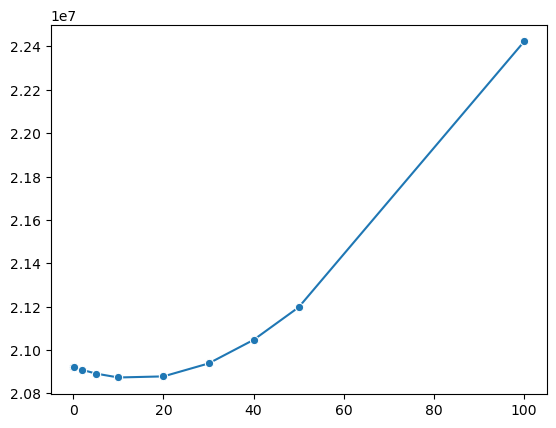

In [14]:
# Training multiple times
alpha = [0.001,0.1,2,5,10,20,30,40,50,100]
min_error = float('inf')
MSES = []
for i in alpha:
    lasso_model =Lasso(alpha=i)
    lasso_model.fit(X_train,Y_train)
    Y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_true=Y_test,y_pred=Y_pred)
    min_error = min(mse,min_error)
    MSES.append(mse)
print(min_error)

sns.lineplot(x=alpha,y=MSES,marker="o")
